## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : CICIDS2017

## Problem Statement

Network traffic in SOC environments generates high volumes of alerts, many of which are false positives that waste analyst time. This project builds a machine learning classifier on the CICIDS2017 dataset to distinguish benign traffic from real attacks and classify attack type, with the goal of reducing analyst triage time and false-positive fatigue  a core problem in real-world SOC operations.

## Data Info
Data Source :https://www.unb.ca/cic/datasets/ids-2017.html

## Data Dictionary — combined.parquet (CICIDS2017)

### Target / metadata

| Column | Type | Description |
|---|---|---|
| Label | category | Target — BENIGN or 1 of 14 attack types |
| Source File | category | Which day's original capture the flow came from |

### Flow features

| Column | Type | Description |
|---|---|---|
| Destination Port | int32 | Destination TCP/UDP port of the flow |
| Flow Duration | int32 | Duration of the flow (µs) |
| Total Fwd Packets | int32 | Packet count, forward direction |
| Total Backward Packets | int32 | Packet count, backward direction |
| Total Length of Fwd Packets | int32 | Total bytes sent, forward direction |
| Total Length of Bwd Packets | int32 | Total bytes sent, backward direction |
| Fwd Packet Length Max/Min/Mean/Std | int16/float32 | Size stats of forward packets (bytes) |
| Bwd Packet Length Max/Min/Mean/Std | int16/float32 | Size stats of backward packets (bytes) |
| Flow Bytes/s | float64 | Flow throughput, bytes/sec |
| Flow Packets/s | float64 | Flow throughput, packets/sec |
| Flow IAT Mean/Std/Max/Min | float64/int32 | Inter-arrival time between packets, whole flow (µs) |
| Fwd IAT Total/Mean/Std/Max/Min | int32/float64 | Inter-arrival time stats, forward packets only |
| Bwd IAT Total/Mean/Std/Max/Min | int32/float64 | Inter-arrival time stats, backward packets only |
| Fwd PSH Flags / Bwd PSH Flags | int8 | PSH flag count, each

In [ ]:
# start you EDA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# things i did before i created the the parquet file 
 did some basic EDA on it then i continued the EDA after i created the parquet file

In [ ]:

# --- 1. Separate label/meta columns from feature columns ---
non_feature_cols = ['Label', 'Source File']
feature_cols = [c for c in data.columns if c not in non_feature_cols]



# --- 2. Downcast to save memory (huge win at 2.8M rows x 80 cols) ---
float_cols = data[feature_cols].select_dtypes(include='float64').columns
int_cols   = data[feature_cols].select_dtypes(include='int64').columns

data[float_cols] = data[float_cols].apply(pd.to_numeric, downcast='float')
data[int_cols]   = data[int_cols].apply(pd.to_numeric, downcast='integer')

# --- 3. Fix the mangled Web Attack labels (encoding artifact from latin1) ---
data['Label'] = data['Label'].str.replace(
    r'Web Attack.*?(Brute Force|XSS|Sql Injection)',
    r'Web Attack - \1',
    regex=True
)

# --- 4. Make categoricals actual category dtype ---
data['Label'] = data['Label'].astype('category')
data['Source File'] = data['Source File'].astype('category')

# --- Sanity check ---
print(data.dtypes.value_counts())
print(f"Memory: {data.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(data['Label'].value_counts())

# --- 8. Save to Parquet ---
out_path = folder_path.parent / "combined.parquet"
data.to_parquet(out_path, index=False, engine='pyarrow')
print(f"Saved to {out_path}")

In [ ]:
df = pd.read_parquet(r'C:\Users\jojah\GA_DSB\capstone project\first topic\MachineLearningCSV\combined.parquet')
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Source File
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## EDA questions

### 1. What is your target column and what does it represent?

In [10]:
target = 'Label'
df[target].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

`Label` is the target it tells you what kind of traffic each flow is: `BENIGN` or one of 14 attack types (DoS Hulk, PortScan, DDoS, DoS GoldenEye, FTP-Patator, SSH-Patator, DoS slowloris, DoS Slowhttptest, Bot, three Web Attack subtypes, Infiltration, Heartbleed).

### 2. Is your target categorical or continuous? Is it balanced? (plot the distribution)

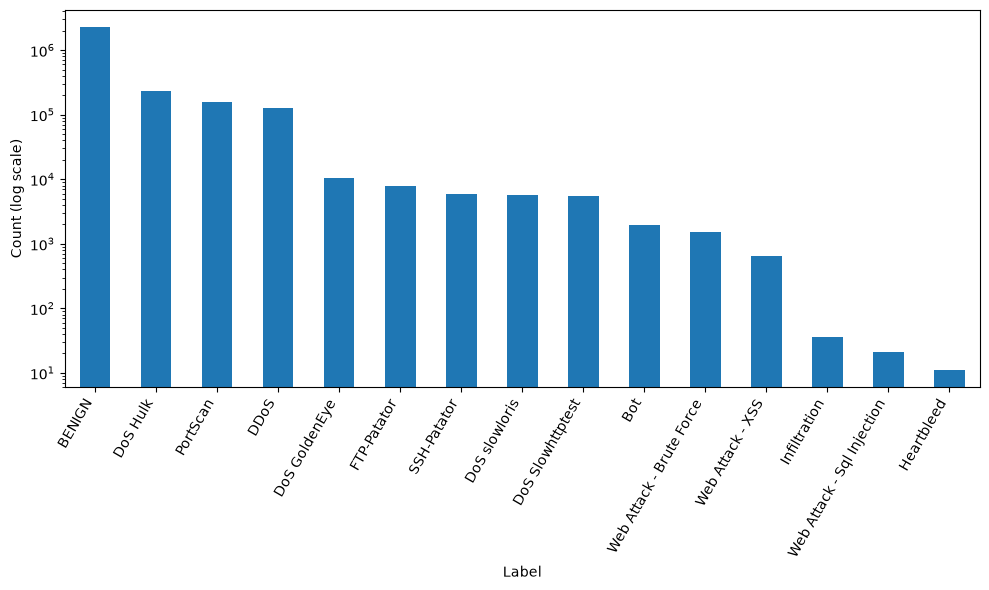

In [12]:
counts = df['Label'].value_counts()
fig, ax = plt.subplots(figsize=(10,6))
counts.plot(kind='bar', ax=ax)
ax.set_yscale('log')   # needed -- the imbalance is extreme
ax.set_ylabel('Count (log scale)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

It's **categorical** (multi-class, 15 classes) and **severely imbalanced**: BENIGN is 80.3% of all rows, the next three (DoS Hulk 8.2%, PortScan 5.6%, DDoS 4.5%) cover almost everything else, and several attack types are tiny Bot 0.07%, Web Attack-XSS 0.02%, Infiltration 0.001%, Heartbleed just 11 rows total (0.0004%).

### 3. What types of features do you have (categorical / numerical)? How many of each?

In [13]:
print(df.dtypes.value_counts())
print("Numeric feature columns:", df.select_dtypes(include='number').shape[1])
print("Categorical columns:", df.select_dtypes(include='category').columns.tolist())

int32       27
int8        18
float64     15
float32      9
int16        7
int64        2
category     1
category     1
Name: count, dtype: int64
Numeric feature columns: 78
Categorical columns: ['Label', 'Source File']


- **Categorical (2):** `Label` (target), `Source File` (metadata -- which day's capture; will drop before modeling, it would leak info)
- **Numerical (78):** everything else (flow duration, packet counts, byte counts, IAT stats, flags, etc.)
- Within those 78, ~12 are really binary flags (0/1) -- `Fwd PSH Flags`, `Fwd URG Flags`, `FIN/SYN/RST/PSH/ACK/URG/CWE/ECE Flag Count` -- and 8 are **constant (zero-variance)**: `Bwd PSH Flags`, `Bwd URG Flags`, and all 6 `*Bulk*` columns. Those 8 carry zero information and should just be dropped.

### 4. How many null values does each feature have? What's your plan for each?

In [16]:
df.isnull().sum()[df.isnull().sum() > 0]

Flow Bytes/s    1358
dtype: int64

In [18]:
for c in ['Flow Bytes/s', 'Flow Packets/s']:
    print(c, np.isinf(df[c]).sum())

Flow Bytes/s 1509
Flow Packets/s 2867


Only one column has actual NaNs: `Flow Bytes/s` -- 1,358 rows (0.05%). But `Flow Bytes/s` also has 1,509 `inf` values and `Flow Packets/s` has 2,867 `inf` values these happen when `Flow Duration` is 0 (division by zero). Combined that's ~4,200 affected rows out of 2.83M (~0.15%).

**Plan:** `df.replace([np.inf, -np.inf], np.nan, inplace=True)`, then either drop those rows (negligible size) or impute with the column median dropping is simplest given how small the fraction is.

### 5. Which features are most correlated with your target, and with each other?

c:\Users\jojah\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jojah\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


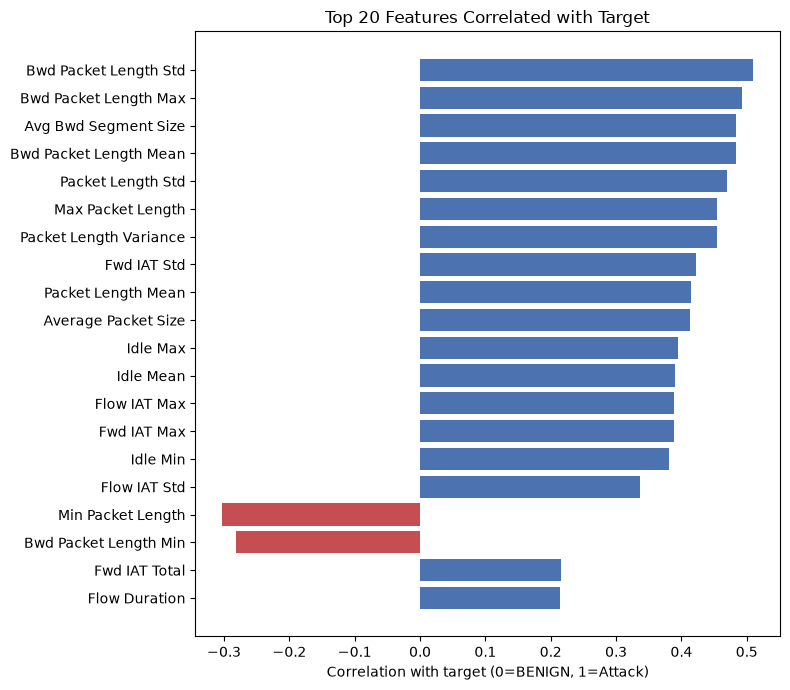

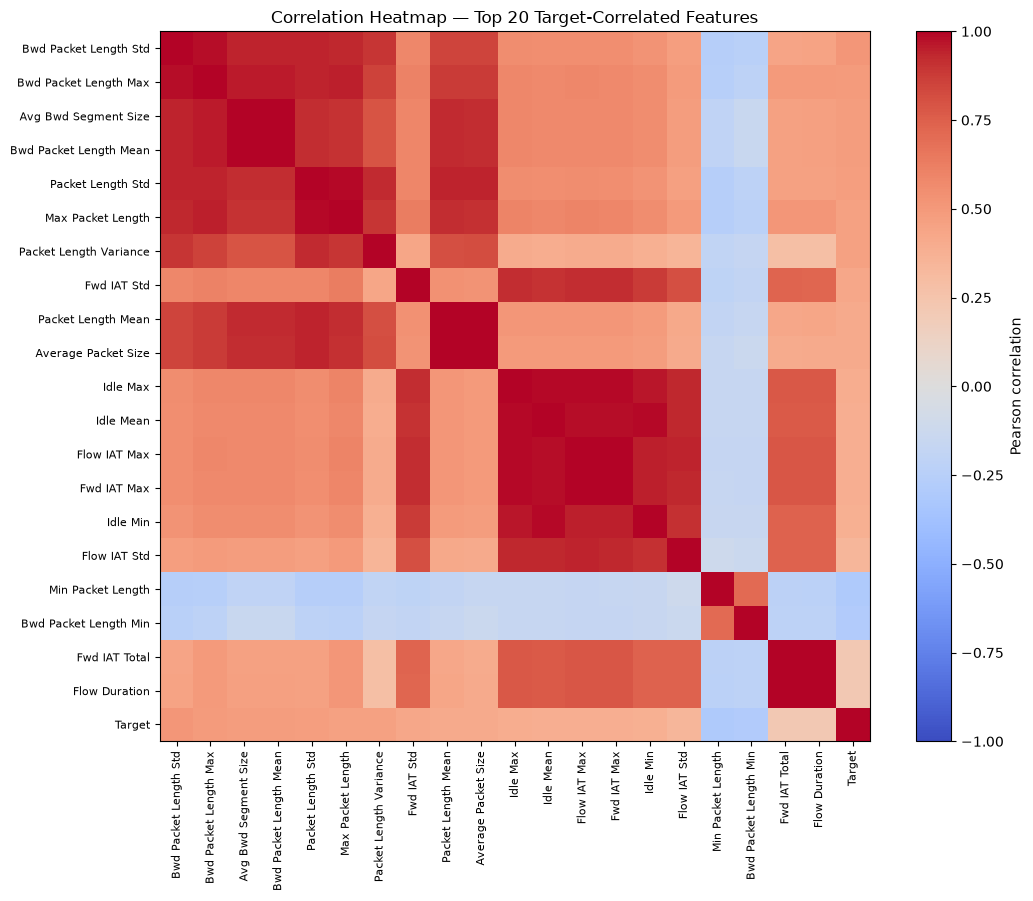

In [22]:
y = (df['Label'] != 'BENIGN').astype(int)
num_df = df.select_dtypes(include='number').replace([np.inf, -np.inf], np.nan)

target_corr = num_df.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
top20 = target_corr.head(20)

# Bar chart
fig, ax = plt.subplots(figsize=(8,7))
colors = ['#4C72B0' if v > 0 else '#C44E52' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('Correlation with target (0=BENIGN, 1=Attack)')
ax.set_title('Top 20 Features Correlated with Target')
plt.tight_layout()
plt.show()

# Heatmap
heat_df = num_df[top20.index].copy()
heat_df['Target'] = y.values
corr_sub = heat_df.corr()

fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(corr_sub.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_sub.columns)))
ax.set_yticks(range(len(corr_sub.columns)))
ax.set_xticklabels(corr_sub.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_sub.columns, fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Heatmap — Top 20 Target-Correlated Features')
plt.tight_layout()
plt.show()


Label is multi-class, so I binarized it (BENIGN=0, attack=1) to compute Pearson correlation against it. Top correlated with target: `Bwd Packet Length Std` (0.51), `Bwd Packet Length Max` (0.49), `Avg/Bwd Packet Length Mean` (0.48), `Packet Length Std` (0.47), `Max Packet Length` (0.45), `Fwd IAT Std` (0.42) -- attacks tend to produce flows with more variable/extreme packet sizes and timing than normal traffic.

This dataset also has a lot of **exact duplicate columns** (known artifact of the original CICIDS2017 CSVs):
- `Avg Fwd Segment Size` = `Fwd Packet Length Mean` (100% identical)
- `Avg Bwd Segment Size` = `Bwd Packet Length Mean` (100% identical)
- `Fwd Header Length.1` = `Fwd Header Length` (100% identical -- literal duplicate column)
- `Subflow Fwd Packets/Bytes` = `Total Fwd Packets`/`Total Length of Fwd Packets`, same for Bwd (100% identical each)
- `Fwd URG Flags` = `CWE Flag Count`, `Fwd PSH Flags` = `SYN Flag Count` (100% identical in this data)

**Plan:** drop one of each duplicate pair plus the 8 zero-variance columns from question 3 -- that alone removes ~15 redundant columns before any modeling.

### 6. Are there outliers? How would you handle them?

In [20]:
q1, q3 = df['Flow Duration'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
(df['Flow Duration'] > upper).mean() * 100

np.float64(18.81435368735346)

Yes a lot of them by the standard IQR rule: 8-23% of rows sit beyond the upper fence on core features like `Flow Duration`, `Flow Bytes/s`, `Bwd Packet Length Max`. But these aren't data errors they're genuinely how attack traffic looks (a flood attack legitimately has huge packet/byte counts). Removing them would strip out exactly the signal that separates attacks from BENIGN.

**Plan:** don't drop them. Either (a) log-transform the heavily skewed byte/duration/IAT columns before using a distance- or linear-based model, or (b) use tree-based models (Random Forest, XGBoost) which don't care about scale/skew at all and are the natural fit here anyway.

# Topic 2 : Mood-based clustering (unsupervised)

## Problem Statement

Without using genre labels at all, can songs be grouped into meaningful 'mood' clusters based on their audio DNA This project applies unsupervised clustering (K-Means/DBSCAN) to audio features to discover natural groupings of tracks, then interprets each cluster's dominant characteristics  e.g., 'high energy + low valence = intense/dark'  as a foundation for a mood-based playlist generator.

## Data Info
Data Source :https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

## Data Dictionary
| Column | Type | Description |
|---|---|---|
| track_id | string | Spotify track ID |
| track_name | string | Song title |
| track_artist | string | Performing artist |
| track_popularity | int | Spotify popularity score, 0–100 |
| track_album_id | string | Spotify album ID |
| track_album_name | string | Album title |
| track_album_release_date | string (date) | Album release date, 1957-01-01 to 2020-01-29 |
| playlist_name | string | Name of the playlist the track was pulled from |
| playlist_id | string | Spotify playlist ID |
| playlist_genre | string | One of: pop, rap, rock, latin, r&b, edm |
| playlist_subgenre | string | One of 24 subgenres nested under the 6 genres |
| danceability | float | 0.0–1.0, how suitable the track is for dancing |
| energy | float | 0.0–1.0, perceptual intensity/activity |
| key | int | Musical key, 0–11 (pitch class notation, 0=C) |
| loudness | float | Overall loudness in dB |
| mode | int (0/1) | Modality — 1 = major, 0 = minor |
| speechiness | float | 0.0–1.0, presence of spoken words |
| acousticness | float | 0.0–1.0, confidence the track is acoustic |
| instrumentalness | float | 0.0–1.0, predicts absence of vocals |
| liveness | float | 0.0–1.0, likelihood the track was performed live |
| valence | float | 0.0–1.0, musical positiveness (happy vs. sad) |
| tempo | float | Estimated tempo in BPM |
| duration_ms | int | Track length in milliseconds (4,000–517,810) |

In [34]:
df2 = pd.read_csv(r'C:\Users\jojah\GA_DSB\capstone project\second topic\spotify\spotify_songs.csv')
df2.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# No target column here since this is unsupervised 
 the goal is to pick a clean, comparable set of 'mood DNA' features before running K-Means/DBSCAN, and check for redundancy between them.

In [35]:
dna_feats = ['energy', 'valence', 'danceability', 'acousticness', 'loudness', 'tempo', 'mode']
df2[dna_feats].describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
energy,0.000175,1.000,0.698619,0.180910
valence,0.000000,0.991,0.510561,0.233146
danceability,0.000000,0.983,0.654850,0.145085
acousticness,0.000000,0.994,0.175334,0.219633
loudness,-46.448000,1.275,-6.719499,2.988436
tempo,0.000000,239.440,120.881132,26.903624
mode,0.000000,1.000,0.565711,0.495671


**Candidate DNA features:** `energy` + `valence` are the two core mood axes (this is basically the valence-arousal model of mood) — energy/dark example in the problem statement is literally high energy + low valence. `danceability` and `acousticness` add useful texture, `loudness`/`tempo` add intensity, `mode` (major/minor) adds a weak happy/sad signal.

**Scale mismatch is the first problem:** `loudness` ranges roughly -46 to +1 dB, `tempo` ranges 0-239 BPM, everything else is 0-1. K-Means/DBSCAN use Euclidean distance, so without scaling, loudness and tempo would completely dominate the clustering.

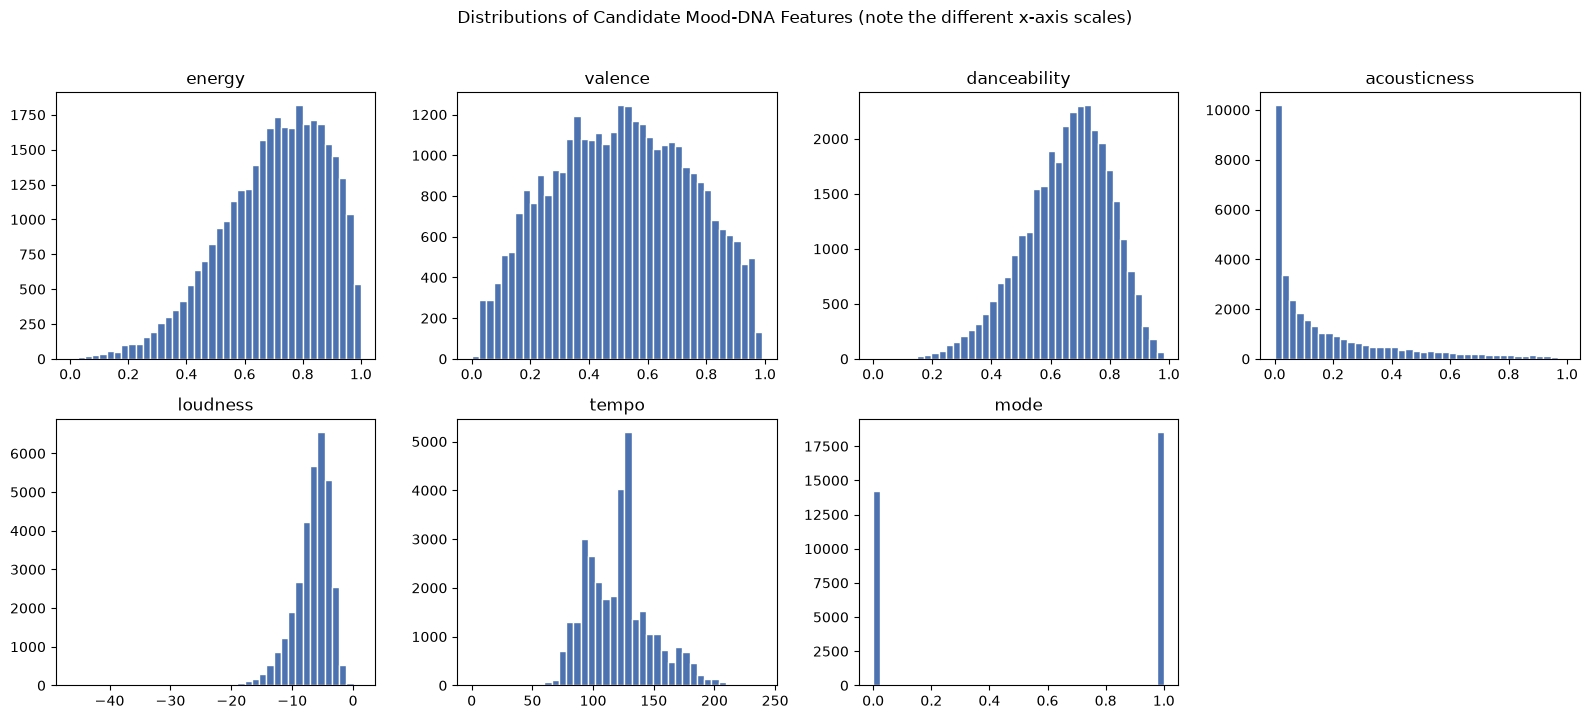

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(16,7))
axes = axes.flatten()
for i, c in enumerate(dna_feats):
    axes[i].hist(df2[c], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(c)
axes[-1].axis('off')
plt.suptitle('Distributions of Candidate Mood-DNA Features (note the different x-axis scales)', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\jojah\AppData\Local\Temp\ipykernel_20656\2375617535.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([df2[c] for c in dna_feats], tick_labels=dna_feats, vert=True)


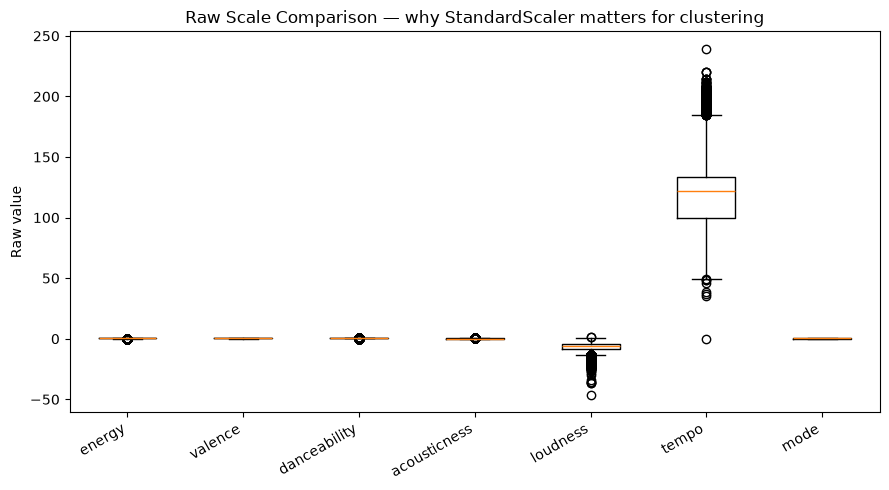

In [37]:
fig, ax = plt.subplots(figsize=(9,5))
ax.boxplot([df2[c] for c in dna_feats], tick_labels=dna_feats, vert=True)
ax.set_title('Raw Scale Comparison — why StandardScaler matters for clustering')
ax.set_ylabel('Raw value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Plan:** run `StandardScaler` on all 7 features before clustering — the boxplot above makes it obvious `loudness` and `tempo` live on a totally different scale than the rest.

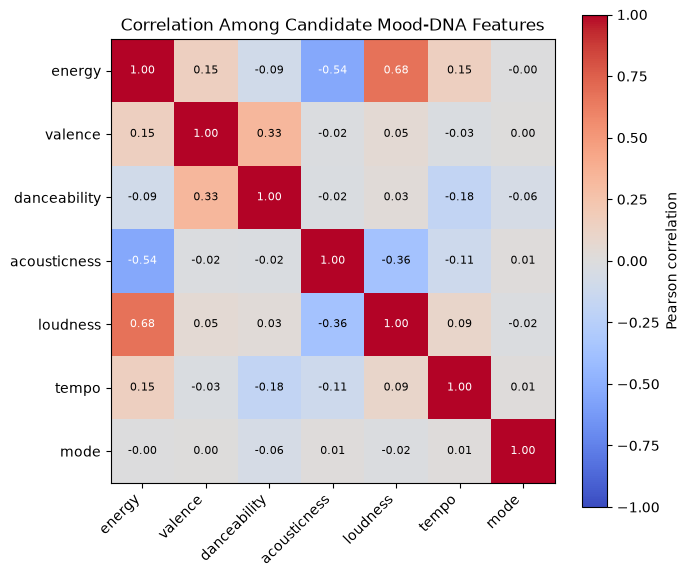

In [38]:
corr = df2[dna_feats].corr()

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(dna_feats))); ax.set_yticks(range(len(dna_feats)))
ax.set_xticklabels(dna_feats, rotation=45, ha='right')
ax.set_yticklabels(dna_feats)
for i in range(len(dna_feats)):
    for j in range(len(dna_feats)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr.values[i,j])>0.5 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Among Candidate Mood-DNA Features')
plt.tight_layout()
plt.show()

**Redundancy check:** `energy` and `loudness` correlate at 0.68 the strongest pair here, and expected (louder tracks read as more energetic). Everything else is fairly independent (|corr| < 0.4). Not severe enough to force dropping a feature, but worth knowing: those two will pull cluster boundaries in a similar direction. Either keep both and let PCA absorb the redundancy, or note it when interpreting cluster centers later.

# Topic 3 : CERT Insider Threat Detection Research

## Problem Statement

Insider threats employees misusing legitimate access to steal data, commit fraud, or sabotage systems they are harder to detect than external attacks because the activity looks normal in isolation. This project builds a user behavior analytics (UEBA) pipeline that aggregates multi-source activity logs (logon, device) into per-user behavioral profiles, then applies anomaly detection to flag employees whose behavior deviates from their baseline  surfacing potential insider threats for SOC review before major damage occurs.

## Data Info
Data Source :https://www.kaggle.com/datasets/mrajaxnp/cert-insider-threat-detection-research/code

## Data Dictionary

| Column | Type | Description |
|---|---|---|
| user | string | User ID (4,000 distinct users) |
| day | date | Calendar date of the activity (2010-01-02 to 2011-06-01) |
| logon_count | int32 | Number of logon events that day |
| logoff_count | int32 | Number of logoff events that day |
| distinct_pc_logon | int32 | Number of distinct PCs the user logged into that day |
| off_hours_logon_count | int32 | Logons outside normal working hours (before 6am/after 8pm) |
| is_weekend | int32 (0/1) | Whether the day falls on a weekend |
| device_connect_count | int32 | USB/removable device connect events that day |
| device_disconnect_count | int32 | USB/removable device disconnect events that day |
| distinct_pc_device | int32 | Distinct PCs on which device activity occurred |
| off_hours_device_count | int32 | Device connect/disconnect events outside working hours |

No target column — this is unsupervised (per-user-per-day behavioral features for anomaly detection, no ground-truth label sourced).

## things i did when i combined the datasets into a parquet file

In [ ]:
# Load raw logon events only keep the columns we actually need, and use
# category dtype for user/pc/activity since they repeat heavily (saves memory)
logon = pd.read_csv(
    r"C:\Users\jojah\GA_DSB\capstone project\third dataset\logon.csv\logon.csv",
    usecols=['date', 'user', 'pc', 'activity'],
    dtype={'user': 'category', 'pc': 'category', 'activity': 'category'}
)
logon['date'] = pd.to_datetime(logon['date'], format='%m/%d/%Y %H:%M:%S')

# Same for device connect/disconnect events
device = pd.read_csv(
    r"C:\Users\jojah\GA_DSB\capstone project\third dataset\device.csv\device.csv",
    usecols=['date', 'user', 'pc', 'activity'],
    dtype={'user': 'category', 'pc': 'category', 'activity': 'category'}
)
device['date'] = pd.to_datetime(device['date'], format='%m/%d/%Y %H:%M:%S')

# Derive shared time features on both event-level tables before aggregating:
# day (grouping key), hour + day-of-week (for off-hours/weekend flags)
for df in (logon, device):
    df['day'] = df['date'].dt.date
    df['hour'] = df['date'].dt.hour
    df['dow'] = df['date'].dt.dayofweek
    df['off_hours'] = ((df['hour'] < 6) | (df['hour'] >= 20)).astype('int8')

# vectorized activity flags — avoid per-group lambdas, they're slow at this scale
# One-hot the activity column into binary flags so groupby().sum() can count them
logon['is_logon'] = (logon['activity'] == 'Logon').astype('int8')
logon['is_logoff'] = (logon['activity'] == 'Logoff').astype('int8')

device['is_connect'] = (device['activity'] == 'Connect').astype('int8')
device['is_disconnect'] = (device['activity'] == 'Disconnect').astype('int8')

# Collapse logon events down to one row per (user, day):
# counts of logons/logoffs, how many distinct PCs they touched, off-hours activity
logon_agg = logon.groupby(['user', 'day'], observed=True).agg(
    logon_count=('is_logon', 'sum'),
    logoff_count=('is_logoff', 'sum'),
    distinct_pc_logon=('pc', 'nunique'),
    off_hours_logon_count=('off_hours', 'sum'),
    dow=('dow', 'first'),  # any row's dow works, they're all the same day
).reset_index()
logon_agg['is_weekend'] = (logon_agg['dow'] >= 5).astype('int8')
logon_agg = logon_agg.drop(columns='dow')  # only needed it to derive is_weekend

# Same per-(user, day) aggregation for device connect/disconnect events
device_agg = device.groupby(['user', 'day'], observed=True).agg(
    device_connect_count=('is_connect', 'sum'),
    device_disconnect_count=('is_disconnect', 'sum'),
    distinct_pc_device=('pc', 'nunique'),
    off_hours_device_count=('off_hours', 'sum'),
).reset_index()

# Cast user back to plain str (was category) so the two frames merge cleanly
logon_agg['user'] = logon_agg['user'].astype(str)
device_agg['user'] = device_agg['user'].astype(str)

# Outer join: keep (user, day) rows that only appear in one of the two logs
merged = pd.merge(logon_agg, device_agg, on=['user', 'day'], how='outer')

# Rows that came from only one side have NaNs on the other side's columns —
# fill those with 0 (no activity that day) and cast back to int
count_cols = ['logon_count', 'logoff_count', 'distinct_pc_logon', 'off_hours_logon_count',
              'is_weekend', 'device_connect_count', 'device_disconnect_count',
              'distinct_pc_device', 'off_hours_device_count']
merged[count_cols] = merged[count_cols].fillna(0).astype('int32')
merged = merged.sort_values(['user', 'day']).reset_index(drop=True)

# Persist the final per-user-per-day feature table for the EDA/modeling notebooks
merged.to_parquet('behavior_main.parquet', index=False)
print("Saved cert_logon_device_features.parquet")

In [39]:
df3 =pd.read_parquet(r'C:\Users\jojah\GA_DSB\capstone project\third dataset\behavior_main.parquet')
df3.head()

,user,day,logon_count,logoff_count,distinct_pc_logon,off_hours_logon_count,is_weekend,device_connect_count,device_disconnect_count,distinct_pc_device,off_hours_device_count
0,AAB0162,2010-01-04,1,1,1,0,0,0,0,0,0
1,AAB0162,2010-01-05,1,1,1,0,0,0,0,0,0
2,AAB0162,2010-01-06,1,1,1,0,0,0,0,0,0
3,AAB0162,2010-01-07,1,1,1,0,0,0,0,0,0
4,AAB0162,2010-01-08,1,1,1,0,0,0,0,0,0


# 1. Target column
This is unsupervised UEBA i'm aggregating behavior, not predicting a label

# 2. Categorical/continuous, balance

N/A for the same reason. What matters instead is the shape of the 9 behavior features:

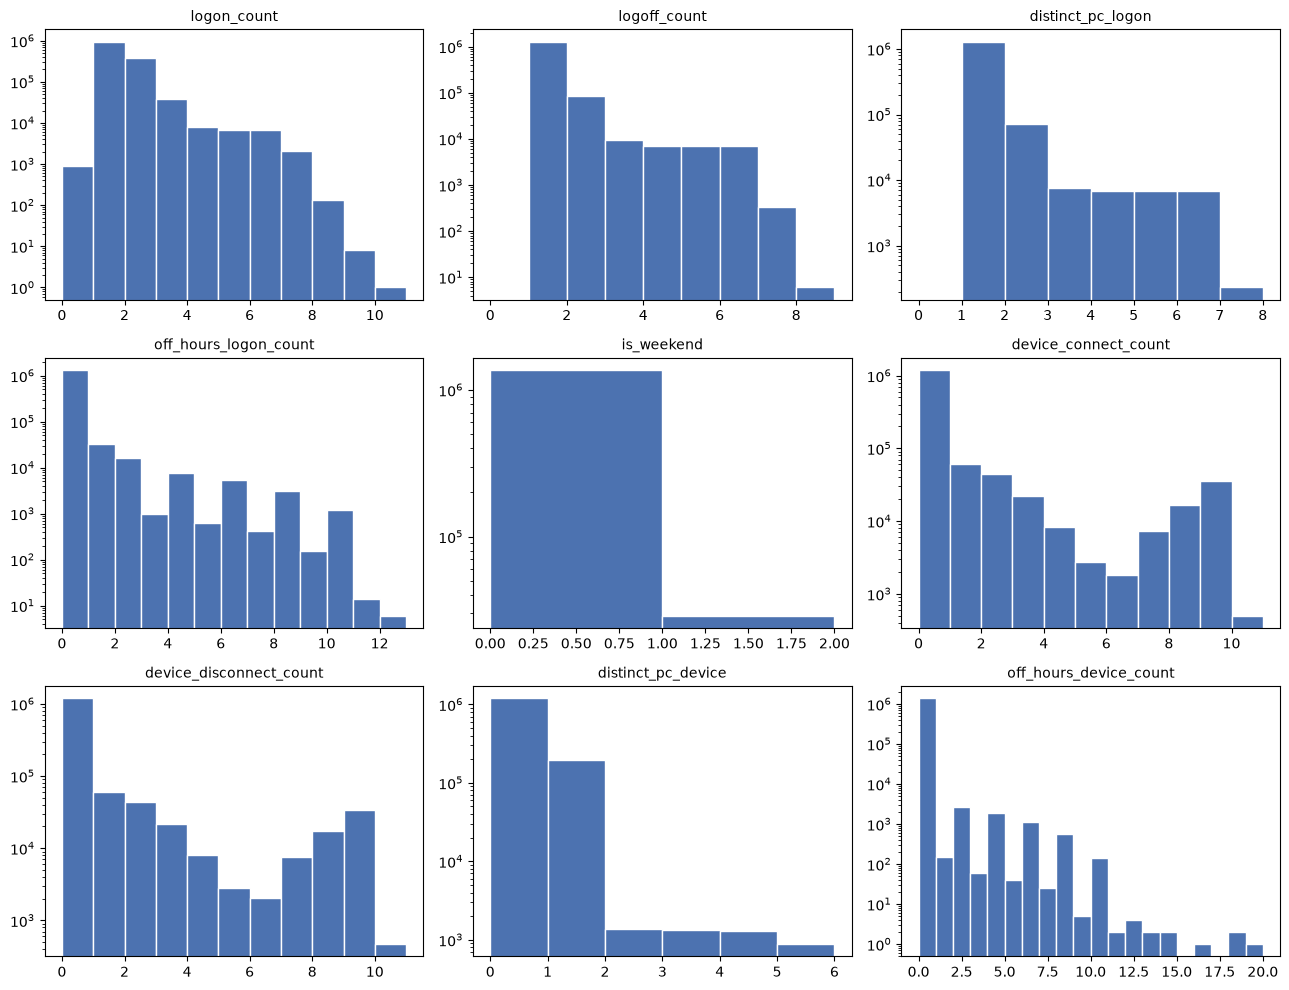

In [41]:
num_cols = ['logon_count','logoff_count','distinct_pc_logon','off_hours_logon_count',
            'is_weekend','device_connect_count','device_disconnect_count',
            'distinct_pc_device','off_hours_device_count']

fig, axes = plt.subplots(3, 3, figsize=(13,10))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    axes[i].hist(df3[c], bins=range(0, int(df3[c].max())+2), color='#4C72B0', edgecolor='white')
    axes[i].set_yscale('log')
    axes[i].set_title(c, fontsize=10)
plt.tight_layout()
plt.show()

Every one of these is heavily zero-inflated (most users do the same handful of logons/logoffs on a normal day and touch zero devices)  that's actually good news for anomaly detection: a "normal day" baseline is tight, so deviations stand out.

# 3.Feature types

In [43]:
print("Identifier columns:", ['user'])
print("Date columns:", ['day'])
print("Numerical columns:", df3.select_dtypes(include='number').columns.tolist())
print("Number of numerical columns:", df3.select_dtypes(include='number').shape[1])

print("\nUnique users:", df3['user'].nunique())
print("is_weekend unique values:", df3['is_weekend'].unique())  # confirms it's really binary (0/1)

Identifier columns: ['user']
Date columns: ['day']
Numerical columns: ['logon_count', 'logoff_count', 'distinct_pc_logon', 'off_hours_logon_count', 'is_weekend', 'device_connect_count', 'device_disconnect_count', 'distinct_pc_device', 'off_hours_device_count']
Number of numerical columns: 9

Unique users: 4000
is_weekend unique values: [0 1]



Identifier (1): user (4,000 distinct)
Date (1): day
Numerical (9): all the count columns above (int32) is_weekend is technically binary/categorical but stored as int

# 4. Nulls

In [44]:
df3.isnull().sum()

user                       0
day                        0
logon_count                0
logoff_count               0
distinct_pc_logon          0
off_hours_logon_count      0
is_weekend                 0
device_connect_count       0
device_disconnect_count    0
distinct_pc_device         0
off_hours_device_count     0
dtype: int64

# 5. Correlation between features

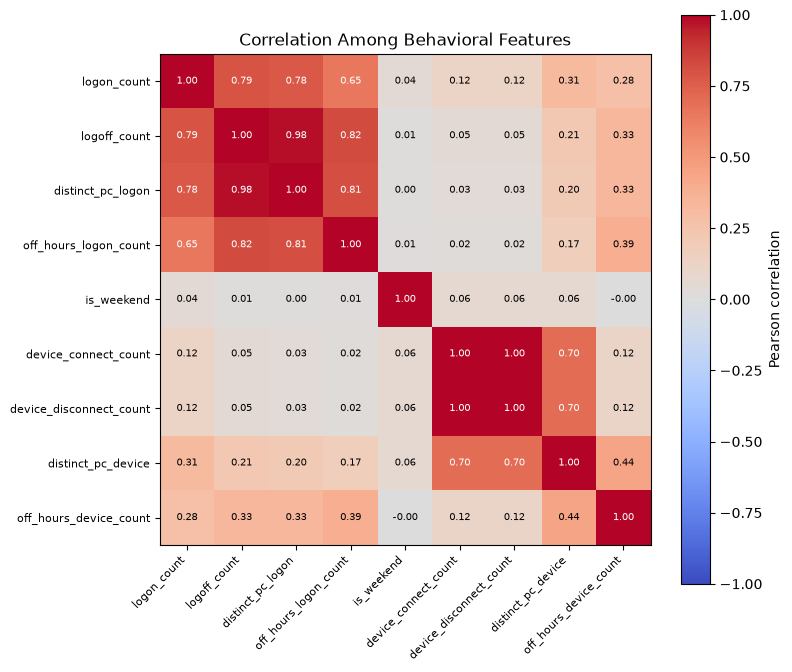

In [49]:
corr = df3[num_cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr.values[i,j])>0.5 else 'black', fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Among Behavioral Features')
plt.tight_layout()
plt.show()

Two pairs stand out:

device_connect_count vs device_disconnect_count: 0.999 — essentially the same signal (every connect gets a disconnect). Keep one, or engineer a combined "device activity" feature instead.
logoff_count vs distinct_pc_logon: 0.981 — near-duplicate too (each PC session logs off once).

Everything else is much weaker (mostly 0.0–0.4), so no other major redundancy to worry about.

# 6. Outliers

In [51]:
for c in num_cols:
    q1, q3 = df3[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    pct = (df3[c] > q3 + 1.5*iqr).mean() * 100
    print(c, f"{pct:.2f}%")

logon_count 1.72%
logoff_count 8.22%
distinct_pc_logon 7.20%
off_hours_logon_count 4.87%
is_weekend 2.08%
device_connect_count 14.27%
device_disconnect_count 14.22%
distinct_pc_device 14.27%
off_hours_device_count 0.48%


user CRM0139 had 19 off-hours device connect/disconnects in a single day (2010-02-03) against a population mean of 0.02 — that's exactly the kind of row your anomaly detector should flag.

Plan: i won't cap or remove outliers before modeling that would delete the positive class. Use them as-is with Isolation Forest / LOF, or z-score the features per-user (comparing each user to their own baseline) rather than globally, since "normal" logon volume varies by role.